In [72]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
plt.style.use('ggplot')

In [74]:
df = pd.read_csv('email.csv')

In [76]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [77]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [78]:
df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [79]:
df = df.iloc[:-1]

In [80]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [81]:
df.shape

(5572, 2)

In [82]:
df.dtypes

Category    object
Message     object
dtype: object

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [84]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [85]:
df.duplicated().sum()

np.int64(415)

In [86]:
df.drop_duplicates(inplace=True)

In [87]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [88]:
df["Category"].value_counts(normalize=True) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

In [89]:
df["Message_Length"] = df["Message"].apply(len)

In [90]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [91]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

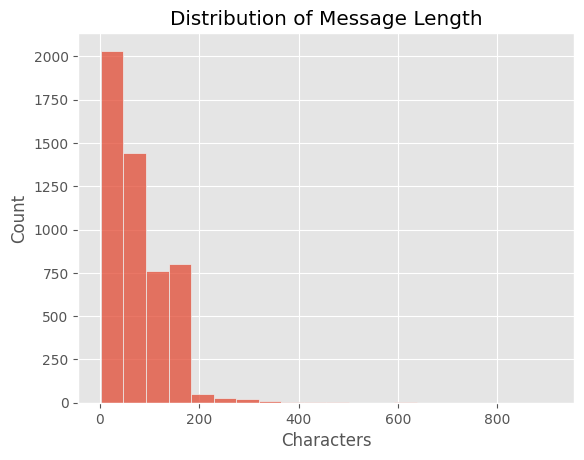

In [92]:
sns.histplot(df["Message_Length"],bins=20)

plt.title('Distribution of Message Length')

plt.xlabel('Characters')

plt.show()

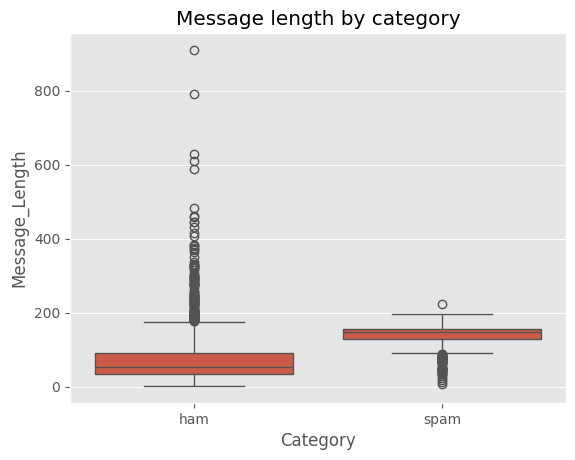

In [93]:
sns.boxplot(
    data = df,
    x= 'Category',
    y= 'Message_Length'
)
plt.title("Message length by category")
plt.show()

In [94]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

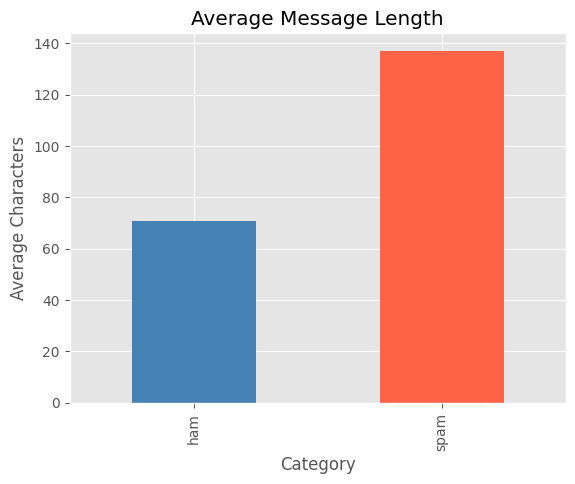

In [95]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind = 'bar',
    color = ['steelblue','tomato']
)
plt.ylabel("Average Characters")
plt.title("Average Message Length")

plt.show()

In [96]:
df['Word_Count'] = df['Message'].apply(lambda x: len(x.split()))

In [97]:
df.head()

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


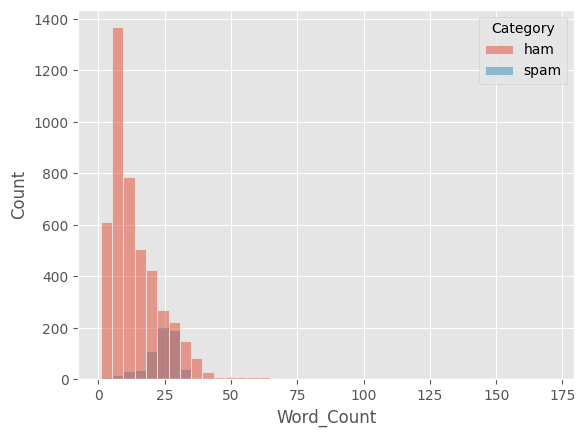

In [98]:
sns.histplot(
    data = df,
    x= 'Word_Count',
    hue= 'Category',
    bins= 40
)
plt.show()

In [99]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [100]:
df.nsmallest(10,'Message_Length')

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [101]:
df.nlargest(10, 'Message_Length')

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [102]:
df[df['Category'] == 'spam'].sample(5)

,Category,Message,Message_Length,Word_Count
761,spam,"Romantic Paris. 2 nights, 2 flights from £79 B...",95,16
4673,spam,Customer service announcement. We recently tri...,152,24
3991,spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...,137,22
5482,spam,URGENT We are trying to contact you Last weeke...,148,27
1544,spam,Hello from Orange. For 1 month's free access t...,156,26


In [103]:
df[df['Category'] == 'ham'].sample(5,random_state=1)

,Category,Message,Message_Length,Word_Count
1258,ham,Am also doing in cbe only. But have to pay.,43,10
5180,ham,Babe! I fucking love you too !! You know? Fuck...,157,34
1296,ham,TELL HER I SAID EAT SHIT.,25,6
4886,ham,Poor girl can't go one day lmao,31,7
266,ham,Same. Wana plan a trip sometme then,35,7


In [104]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})    

In [105]:
df.head()

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [106]:
import warnings
warnings.filterwarnings('ignore')

In [107]:
from sklearn.model_selection import train_test_split 

In [108]:
X = df['Message']

In [109]:
y = df['Category']

In [110]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english',max_features=5000,ngram_range=(1,2))

In [112]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [113]:
X_test_tfidf = tfidf.transform(X_test)

In [114]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [115]:
models = {
    'Naive Bayes':(
         MultinomialNB(),
        {
            'alpha': [0.1,0.5,1,2,5]
        }
    ),

    'Logistic Regression':(
        LogisticRegression(
            class_weight = 'balanced',
            max_iter= 1000
        ),
        {
            'C' : [0.01,0.1,1,10,100]
        }
    ),

    'Linear SVM':(
        LinearSVC(
            class_weight='balanced'
        ),
        {
            'C':[0.01,0.1,1,10]
        }
    ),

    'Random Forest':(
        RandomForestClassifier(
            class_weight='balanced'
        ),
        {
            'n_estimators':[100,200,300],
            'max_depth':[10,20,None],
            'min_samples_split':[2,5,10]
        }
    ),

    'Decision Tree':(
        DecisionTreeClassifier(
            class_weight='balanced'
        ),
        {
            'max_depth':[5,10,20,None],
            'min_samples_split':[2,5,10]
        }
    ),

    'Gradient Boosting':(
        GradientBoostingClassifier(),
        {
            
            'n_estimators':[100,200,300],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[3,5]
        }
    ),

    'KNN':(
        KNeighborsClassifier(),
        {
            'n_neighbors':[3,5,7,9]
        }
    )
}

In [116]:
results = []
best_models={}
for name, (model,params) in models.items():
    search=RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    search.fit(X_train_tfidf,y_train)

    best_model = search.best_estimator_
    best_models[name]=best_model
    predictions=best_model.predict(X_test_tfidf)

    accuracy=accuracy_score(y_test,predictions)
    precision=precision_score(y_test,predictions)
    recall=recall_score(y_test,predictions)
    f1=f1_score(y_test,predictions)

    try:
        auc = roc_auc_score(y_test,best_model.decision_function(X_test_tfidf))
    except:
        try:
            auc= roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf) [:,1]
            )
        except:
            auc = np.nan

    results.append({
        'Model':name,
        'Accuracy':accuracy,
        'Precision':precision,
        'Recall':recall,
        'F1 score':f1,
        'ROC AUC':auc,
        'Best Params':search.best_params_
    })

In [117]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by = ['F1 score','ROC AUC'],
    ascending=False
)

In [118]:
results_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC,Best Params
1,Logistic Regression,0.974806,0.898438,0.898438,0.898438,0.988316,{'C': 10}
3,Random Forest,0.976744,0.990566,0.820312,0.897436,0.986691,"{'n_estimators': 300, 'min_samples_split': 5, ..."
2,Linear SVM,0.973837,0.897638,0.890625,0.894118,0.986674,{'C': 0.1}
0,Naive Bayes,0.973837,0.954955,0.828125,0.887029,0.989699,{'alpha': 0.1}
5,Gradient Boosting,0.961240,0.968085,0.710938,0.819820,0.967588,"{'n_estimators': 300, 'max_depth': 5, 'learnin..."
4,Decision Tree,0.956395,0.848739,0.789062,0.817814,0.867062,"{'min_samples_split': 10, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.792286,{'n_neighbors': 3}


In [119]:
results_df.style.background_gradient(
    cmap='Greens',
    subset= [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 score',
        'ROC AUC']
)

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC,Best Params
1,Logistic Regression,0.974806,0.898438,0.898438,0.898438,0.988316,{'C': 10}
3,Random Forest,0.976744,0.990566,0.820312,0.897436,0.986691,"{'n_estimators': 300, 'min_samples_split': 5, 'max_depth': None}"
2,Linear SVM,0.973837,0.897638,0.890625,0.894118,0.986674,{'C': 0.1}
0,Naive Bayes,0.973837,0.954955,0.828125,0.887029,0.989699,{'alpha': 0.1}
5,Gradient Boosting,0.961240,0.968085,0.710938,0.819820,0.967588,"{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}"
4,Decision Tree,0.956395,0.848739,0.789062,0.817814,0.867062,"{'min_samples_split': 10, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.792286,{'n_neighbors': 3}


In [120]:
results_df.reset_index(inplace=True)

In [121]:
results_df.drop(columns = 'index',inplace=True )

In [122]:
results_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC,Best Params
0,Logistic Regression,0.974806,0.898438,0.898438,0.898438,0.988316,{'C': 10}
1,Random Forest,0.976744,0.990566,0.820312,0.897436,0.986691,"{'n_estimators': 300, 'min_samples_split': 5, ..."
2,Linear SVM,0.973837,0.897638,0.890625,0.894118,0.986674,{'C': 0.1}
3,Naive Bayes,0.973837,0.954955,0.828125,0.887029,0.989699,{'alpha': 0.1}
4,Gradient Boosting,0.961240,0.968085,0.710938,0.819820,0.967588,"{'n_estimators': 300, 'max_depth': 5, 'learnin..."
5,Decision Tree,0.956395,0.848739,0.789062,0.817814,0.867062,"{'min_samples_split': 10, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,0.792286,{'n_neighbors': 3}


In [123]:
best_model_name = results_df.iloc[0]['Model']

In [124]:
best_model_name

'Logistic Regression'

In [125]:
best_model = best_models[best_model_name]

In [126]:
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


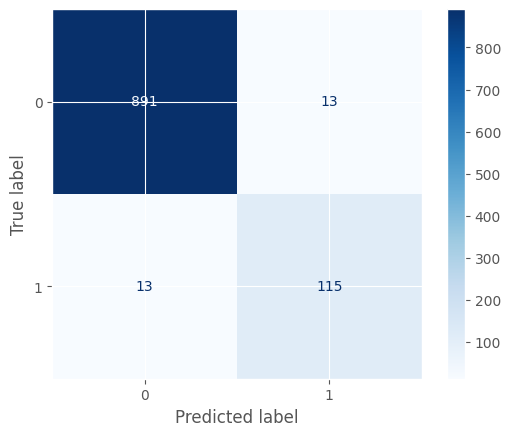

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap = 'Blues'
)

plt.show()



In [134]:
emails = [
    "Congratulations! You won new IPhone. Click here now.",
    "Hey, are we still meeting tomorrow at 10 AM?",
    "URGENT! Claim your $1000 Walmart gift card today.",
    "Can you pick up some groceries on your way home?",
    "You have been selected to receive a $500 Amazon gift card.",
    "Happy Birthday! Wishing you a wonderful day ahead.",
    "Limited-time offer! Buy one, get one free. Shop today!",
    "I'll send you the project files once I reach home.",
    "Claim your lottery prize by clicking the link below.",
    "Let's have lunch together this weekend."
]
emails_vectorized = tfidf.transform(emails)
predictions = best_model.predict(emails_vectorized)

for email,prediction in zip(emails,predictions):
    label = 'Spam' if prediction ==1 else 'Ham' 
    print(f"Email : {email}")
    print(f"Prediction : {label}")
    print("-"*70)

Email : Congratulations! You won new IPhone. Click here now.
Prediction : Spam
----------------------------------------------------------------------
Email : Hey, are we still meeting tomorrow at 10 AM?
Prediction : Ham
----------------------------------------------------------------------
Email : URGENT! Claim your $1000 Walmart gift card today.
Prediction : Spam
----------------------------------------------------------------------
Email : Can you pick up some groceries on your way home?
Prediction : Ham
----------------------------------------------------------------------
Email : You have been selected to receive a $500 Amazon gift card.
Prediction : Spam
----------------------------------------------------------------------
Email : Happy Birthday! Wishing you a wonderful day ahead.
Prediction : Ham
----------------------------------------------------------------------
Email : Limited-time offer! Buy one, get one free. Shop today!
Prediction : Ham
----------------------------------

In [135]:
import pickle

with open("spam_classifier.pkl", "wb") as file:

    pickle.dump(best_model,file)

In [137]:
with open("tfdif_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf,file)

print('Success')

Success


In [141]:
import pickle
with open("spam_classifier.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("tfdif_vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

In [142]:
email = [
    "Congratulations! You have won $1000. Click here to claim."
]

email_vector = loaded_vectorizer.transform(email)
prediction = loaded_model.predict(email_vector)[0]

In [143]:
print('Spam' if prediction ==1 else 'Ham')

Spam
